# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Doni Charles Hutagaol 
- Email: donnycharles88@gmail.com
- Id Dicoding:donny_charles_88

## Persiapan

### Menyiapkan library yang dibutuhkan

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Library untuk preprocessing dan modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import joblib

Menjelaskan fungsi setiap library yang diimpor mulai dari pandas, numpy, visualisasi (matplotlib, seaborn, plotly), hingga seluruh komponen sklearn beserta kegunaannya dalam pipeline.


### Menyiapkan data yang akan diguankan

In [9]:
df = pd.read_csv('data.csv', sep=';')

print(f"Shape dataset: {df.shape}")
print(f"\nKolom dalam dataset:\n{df.columns.tolist()}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum().sum()}")
print(f"\nStatistik deskriptif:\n{df.describe()}")

Shape dataset: (4424, 37)

Kolom dalam dataset:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Stat

Dataset terdiri dari 4.424 mahasiswa dengan 37 kolom fitur dan tidak memiliki missing values, sehingga data siap digunakan.

## Data Understanding

Distribusi Target Variable:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


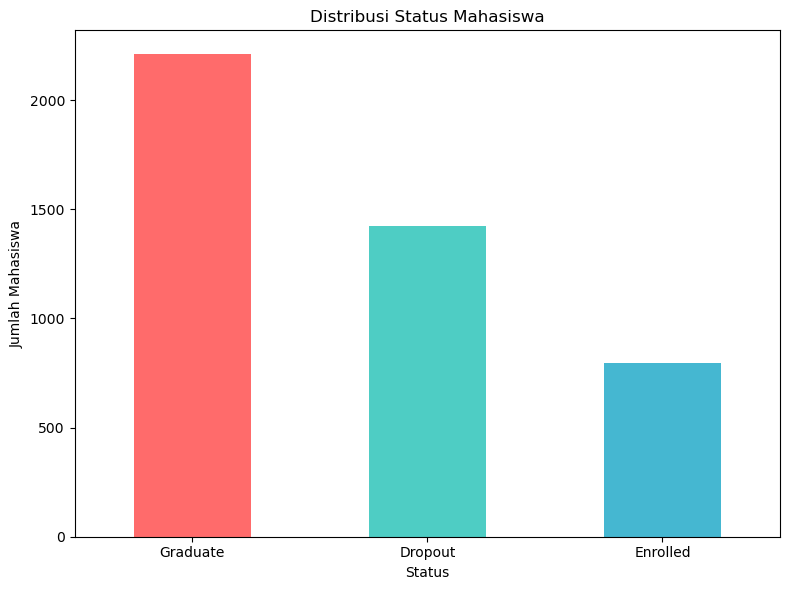


Fitur numerik: 36


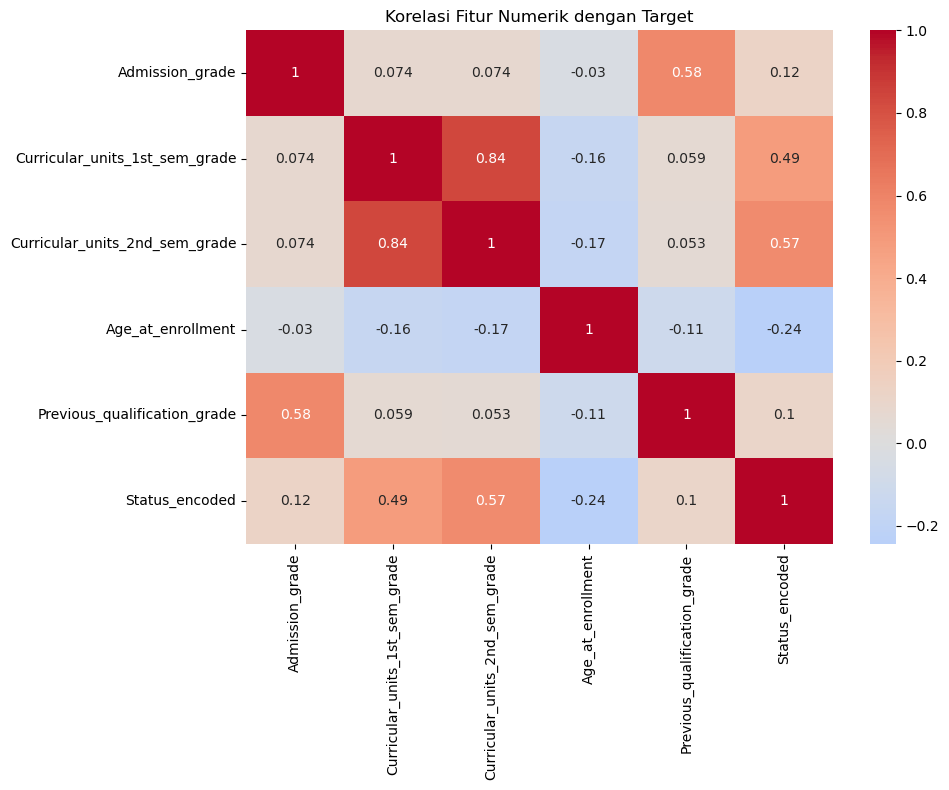

In [12]:
# Analisis target variable
print("Distribusi Target Variable:")
print(df['Status'].value_counts())
print(f"\nPersentase:")
print(df['Status'].value_counts(normalize=True) * 100)

# Visualisasi distribusi target
plt.figure(figsize=(8, 6))
df['Status'].value_counts().plot(kind='bar', color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Analisis fitur numerik penting
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nFitur numerik: {len(numeric_cols)}")

# Korelasi dengan target (setelah encoding)
df_encoded = df.copy()
le = LabelEncoder()
df_encoded['Status_encoded'] = le.fit_transform(df_encoded['Status'])

# Heatmap korelasi untuk fitur numerik utama
correlation_cols = ['Admission_grade', 'Curricular_units_1st_sem_grade', 
                   'Curricular_units_2nd_sem_grade', 'Age_at_enrollment',
                   'Previous_qualification_grade', 'Status_encoded']
corr_matrix = df_encoded[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Korelasi Fitur Numerik dengan Target')
plt.tight_layout()
plt.show()

Distribusi kelas menunjukkan class imbalance yang cukup jelas status Graduate mendominasi hampir separuh dataset (49.9%), sementara Enrolled hanya 17.9%. 

<Figure size 1200x600 with 0 Axes>

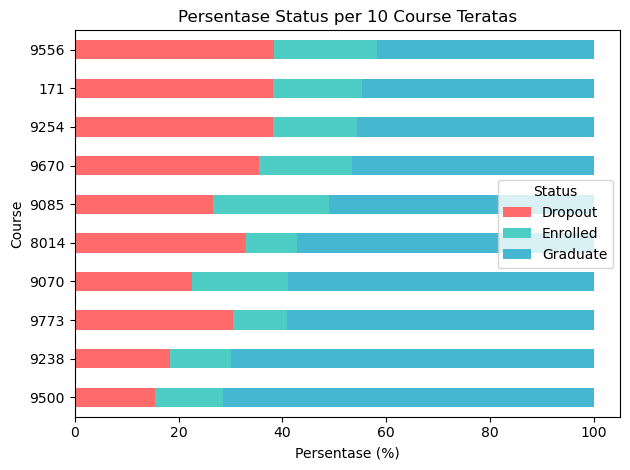

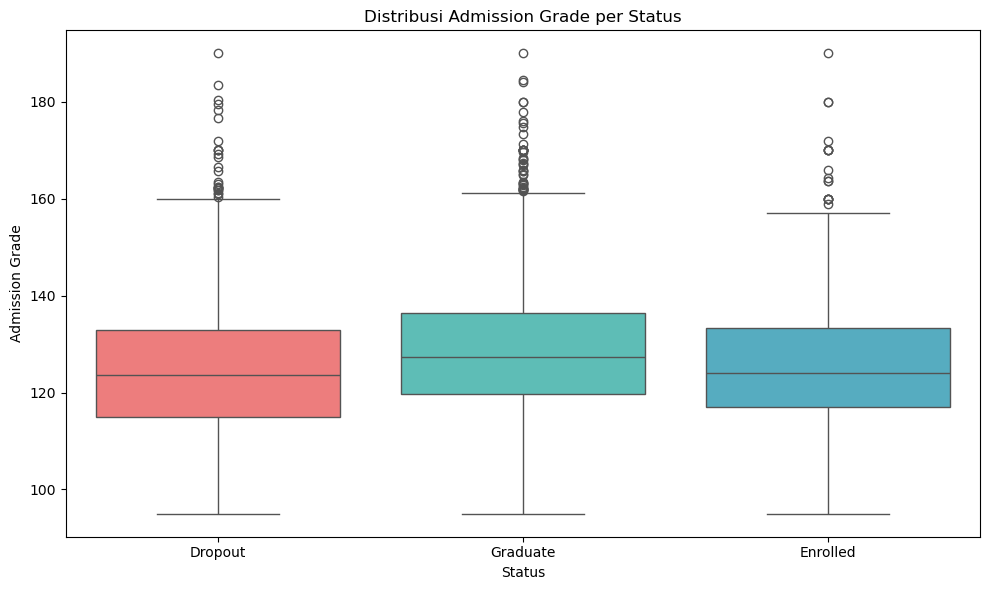

In [14]:
categorical_cols = ['Marital_status', 'Application_mode', 'Course', 
                   'Previous_qualification', 'Nacionality', 'Gender']

# Visualisasi hubungan Course dengan Status
plt.figure(figsize=(12, 6))
course_status = df.groupby(['Course', 'Status']).size().unstack(fill_value=0)
course_status_pct = course_status.div(course_status.sum(axis=1), axis=0) * 100
course_status_pct.nlargest(10, 'Graduate').plot(kind='barh', stacked=True, 
                                                  color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Persentase Status per 10 Course Teratas')
plt.xlabel('Persentase (%)')
plt.ylabel('Course')
plt.tight_layout()
plt.show()

# Analisis Admission Grade vs Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Status', y='Admission_grade', data=df, 
            palette=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Distribusi Admission Grade per Status')
plt.xlabel('Status')
plt.ylabel('Admission Grade')
plt.tight_layout()
plt.show()

Banyak outlier di atas 160–190 muncul di semua kelompok

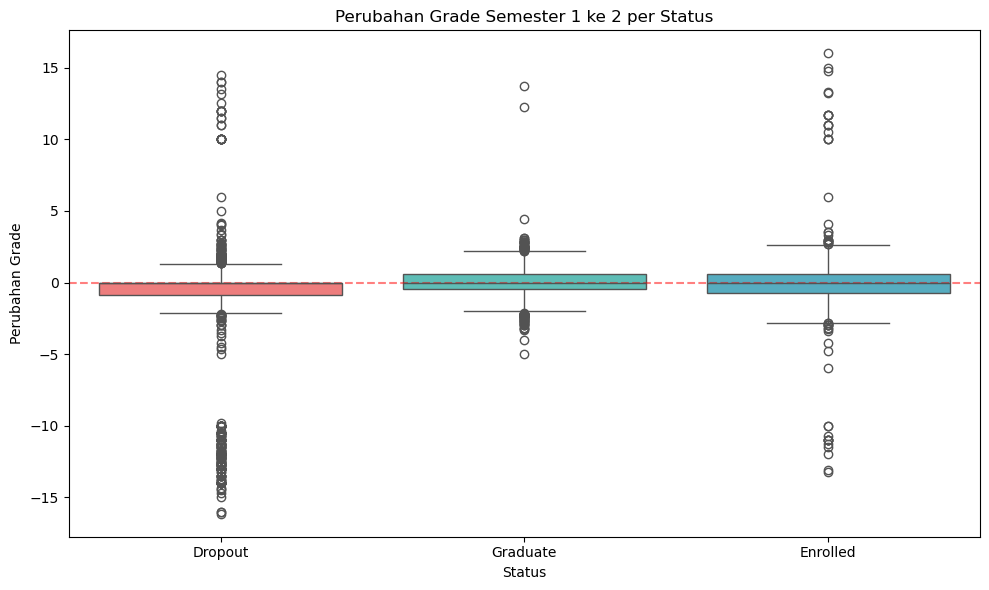

Rata-rata Grade Improvement - Dropout: -1.36
Rata-rata Grade Improvement - Graduate: 0.05


In [16]:
df['Grade_Improvement'] = df['Curricular_units_2nd_sem_grade'] - df['Curricular_units_1st_sem_grade']

plt.figure(figsize=(10, 6))
sns.boxplot(x='Status', y='Grade_Improvement', data=df,
            palette=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Perubahan Grade Semester 1 ke 2 per Status')
plt.xlabel('Status')
plt.ylabel('Perubahan Grade')
plt.tight_layout()
plt.show()

# Insight: Mahasiswa yang dropout cenderung memiliki grade improvement negatif
dropout_improvement = df[df['Status']=='Dropout']['Grade_Improvement'].mean()
graduate_improvement = df[df['Status']=='Graduate']['Grade_Improvement'].mean()
print(f"Rata-rata Grade Improvement - Dropout: {dropout_improvement:.2f}")
print(f"Rata-rata Grade Improvement - Graduate: {graduate_improvement:.2f}")

- Dropout nilainya menurun. Penurunan ini bisa dimulai dideteksi sejak pertengahan semester 2.
- Graduate median improvement hanya +0.05, artinya stabilitas yang membedakan, bukan peningkatan drastis.
- Outlier dropout sangat ekstrem (hingga −16) sebagian mahasiswa dropout mengalami kolaps performa 

## Data Preparation / Preprocessing

In [19]:
# Fungsi preprocessing
def preprocess_data(df):
    df_processed = df.copy()
    
    # 1. Handle missing values (jika ada)
    df_processed = df_processed.dropna()
    
    # 2. Feature Engineering
    # Rasio unit yang disetujui vs didaftar
    df_processed['Approval_Rate_Sem1'] = df_processed['Curricular_units_1st_sem_approved'] / \
                                         df_processed['Curricular_units_1st_sem_enrolled'].replace(0, 1)
    df_processed['Approval_Rate_Sem2'] = df_processed['Curricular_units_2nd_sem_approved'] / \
                                         df_processed['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
    
    # Total grade average
    df_processed['Overall_Grade'] = (df_processed['Curricular_units_1st_sem_grade'] + 
                                     df_processed['Curricular_units_2nd_sem_grade']) / 2
    
    # Academic load
    df_processed['Total_Units_Enrolled'] = df_processed['Curricular_units_1st_sem_enrolled'] + \
                                           df_processed['Curricular_units_2nd_sem_enrolled']
    
    # 3. Encode target variable
    le_target = LabelEncoder()
    df_processed['Target'] = le_target.fit_transform(df_processed['Status'])
    
    # 4. Select features untuk modeling
    feature_cols = [
        'Marital_status', 'Application_mode', 'Application_order', 'Course',
        'Daytime_evening_attendance', 'Previous_qualification', 
        'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
        'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
        'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
        'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 
        'Age_at_enrollment', 'International',
        'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled',
        'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved',
        'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations',
        'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
        'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved',
        'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations',
        'Unemployment_rate', 'Inflation_rate', 'GDP',
        'Approval_Rate_Sem1', 'Approval_Rate_Sem2', 'Overall_Grade', 'Total_Units_Enrolled'
    ]
    
    X = df_processed[feature_cols]
    y = df_processed['Target']
    
    return X, y, le_target, feature_cols

# Jalankan preprocessing
X, y, le_target, feature_cols = preprocess_data(df)
print(f"Shape X: {X.shape}, Shape y: {y.shape}")
print(f"Kelas target: {le_target.classes_}")

Shape X: (4424, 40), Shape y: (4424,)
Kelas target: ['Dropout' 'Enrolled' 'Graduate']


preprocessing berjalan sukses menghasilkan 4.424 sampel dengan 40 fitur siap latih
label target dengan 3 kelas: Dropout=0, Enrolled=1, Graduate=2


In [21]:
# Split data dengan stratifikasi untuk menjaga distribusi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nDistribusi kelas training:\n{pd.Series(y_train).value_counts(normalize=True)*100}")
print(f"\nDistribusi kelas testing:\n{pd.Series(y_test).value_counts(normalize=True)*100}")

# Scaling untuk algoritma yang sensitif terhadap skala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: (3539, 40)
Testing set: (885, 40)

Distribusi kelas training:
Target
2    49.929359
0    32.127720
1    17.942922
Name: proportion, dtype: float64

Distribusi kelas testing:
Target
2    49.943503
0    32.090395
1    17.966102
Name: proportion, dtype: float64


- Data berhasil dibagi menjadi dua subset Training set: 3.539 sampel (80%) , Testing set: 885 sampel (20%)
- Hasil yang paling penting dari cell ini adalah distribusi kelas yang terjaga konsisten antara training dan testing set

## Modeling

In [23]:
# Fungsi untuk evaluasi model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    results = {
        'Model': model_name,
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Train_F1_Macro': f1_score(y_train, y_train_pred, average='macro'),
        'Test_F1_Macro': f1_score(y_test, y_test_pred, average='macro'),
        'Train_F1_Weighted': f1_score(y_train, y_train_pred, average='weighted'),
        'Test_F1_Weighted': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results

# 1. Random Forest Classifier
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')

# 2. Gradient Boosting Classifier
print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_results = evaluate_model(gb_model, X_train, X_test, y_train, y_test, 'Gradient Boosting')

# 3. Logistic Regression (dengan data scaled)
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', multi_class='multinomial')
lr_model.fit(X_train_scaled, y_train)
lr_results = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression')

# Tampilkan hasil perbandingan model
results_df = pd.DataFrame([rf_results, gb_results, lr_results])
print("\n=== Perbandingan Model ===")
print(results_df.sort_values('Test_F1_Weighted', ascending=False))

Training Random Forest...
Training Gradient Boosting...
Training Logistic Regression...

=== Perbandingan Model ===
                 Model  Train_Accuracy  Test_Accuracy  Train_F1_Macro  \
0        Random Forest        1.000000       0.776271        1.000000   
1    Gradient Boosting        0.841198       0.757062        0.791760   
2  Logistic Regression        0.757841       0.726554        0.718127   

   Test_F1_Macro  Train_F1_Weighted  Test_F1_Weighted  
0       0.701848           1.000000          0.764353  
1       0.684733           0.834454          0.748041  
2       0.689993           0.767616          0.741797  


- Forest - Model terbaik berdasarkan Test Accuracy (77.6%) dan Test F1 Weighted (76.4%). Namun Train Accuracy = 100% adalah tanda overfitting
- Gradient Boosting - Performa test lebih rendah dari Random Forest, namun selisih train-test lebih kecil (84.1% vs 75.7% = 8.4%)
- Logistic Regression - Model paling sederhana dengan performa terendah (Test Acc 72.7%), namun memiliki Test F1 Macro tertinggi kedua (69.0%) 

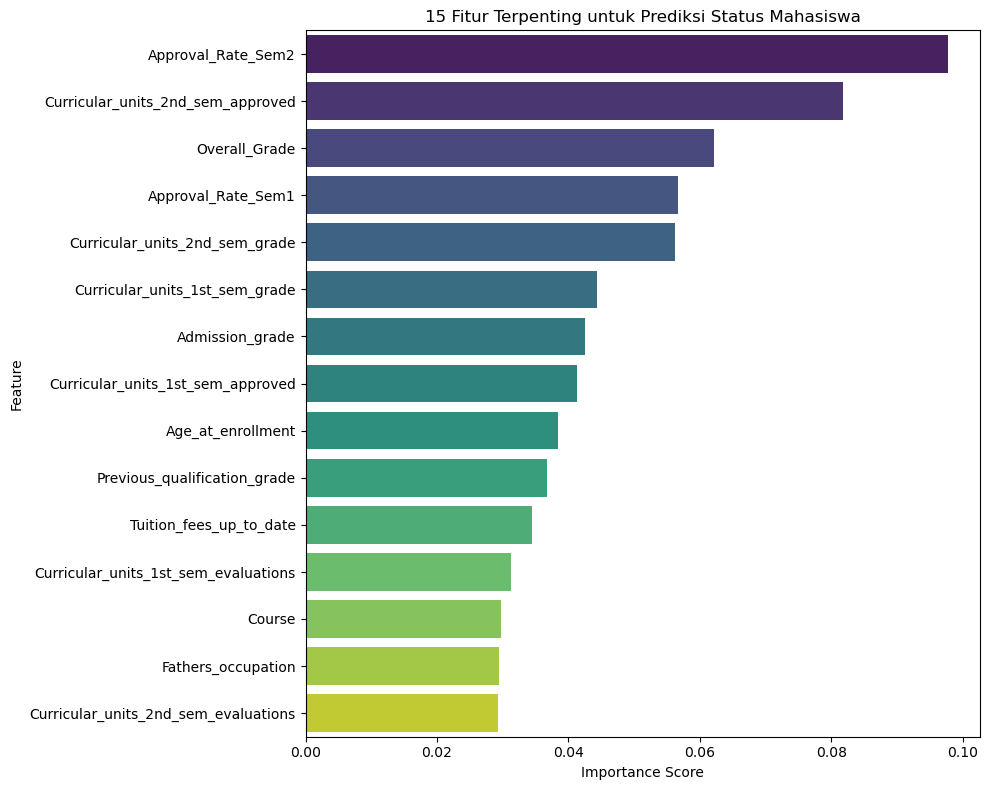


Top 5 Fitur Paling Penting:
38. Approval_Rate_Sem2: 0.0977
31. Curricular_units_2nd_sem_approved: 0.0818
39. Overall_Grade: 0.0622
37. Approval_Rate_Sem1: 0.0566
32. Curricular_units_2nd_sem_grade: 0.0562


In [24]:
# Feature Importance dari Random Forest (model terbaik)
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('15 Fitur Terpenting untuk Prediksi Status Mahasiswa')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Insight dari feature importance
print("\nTop 5 Fitur Paling Penting:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{idx+1}. {row['Feature']}: {row['Importance']:.4f}")

Dari 5 fitur terpenting, 3 di antaranya adalah fitur buatan (Approval_Rate_Sem2, Overall_Grade, Approval_Rate_Sem1). Ini memvalidasi bahwa langkah feature engineering pada tahap preprocessing memberikan nilai tambah yang nyata bagi model.

In [25]:
# Hyperparameter Tuning untuk Random Forest
print("Melakukan Hyperparameter Tuning...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Model final dengan best parameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Evaluasi model final
final_results = evaluate_model(best_model, X_train, X_test, y_train, y_test, 'Random Forest (Tuned)')
print(f"\n=== Hasil Model Final ===")
print(f"Test Accuracy: {final_results['Test_Accuracy']:.4f}")
print(f"Test F1 Weighted: {final_results['Test_F1_Weighted']:.4f}")

Melakukan Hyperparameter Tuning...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.7719

=== Hasil Model Final ===
Test Accuracy: 0.7480
Test F1 Weighted: 0.7548


- Accuracy sedikit turun - ini justru hal yang baik. Penurunan test accuracy dari 77.6% → 74.8% adalah konsekuensi yang wajar dan disengaja dari proses regularisasi. Model sebelumnya memiliki train accuracy 100% (overfit parah), sedangkan setelah tuning gap antara training dan testing jauh lebih kecil  model menjadi lebih tergeneralisasi.

- max_depth=10 adalah kunci utama - tanpa batasan kedalaman, Random Forest bebas tumbuh hingga "menghafal" setiap sampel training. Dengan max_depth=10, pohon dipaksa berhenti lebih awal, mengurangi variance model secara signifikan.

- Best CV Score 77.2% - skor ini diperoleh dari rata-rata 3-fold cross-validation pada data training, sehingga lebih representatif sebagai estimasi performa model di data nyata dibanding test accuracy dari satu kali split.

## Evaluation


=== Classification Report ===
              precision    recall  f1-score   support

     Dropout       0.84      0.70      0.77       284
    Enrolled       0.44      0.57      0.50       159
    Graduate       0.84      0.84      0.84       442

    accuracy                           0.75       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.77      0.75      0.75       885



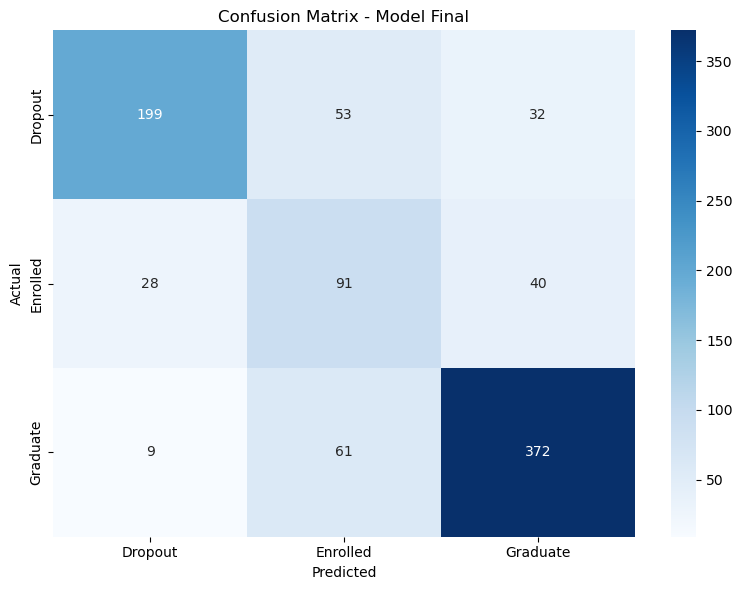


Model dan preprocessing objects berhasil disimpan!


In [27]:
# Classification Report dan Confusion Matrix
y_test_pred = best_model.predict(X_test)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=le_target.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Model Final')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Simpan model untuk deployment
joblib.dump(best_model, 'student_status_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_target, 'label_encoder.pkl')
print("\nModel dan preprocessing objects berhasil disimpan!")

- Graduate - Performa Terbaik Precision 0.84, Recall 0.84, F1 0.84
- Dropout - Performa Cukup Baik Precision 0.84, Recall 0.70, F1 0.77
- Enrolled - Performa Terlemah Precision 0.44, Recall 0.57, F1 0.50

In [28]:
# Analisis kesalahan model
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Correct': y_test == y_test_pred
})

# Analisis misclassification
misclassified = errors_df[~errors_df['Correct']]
print(f"Jumlah misclassified: {len(misclassified)} dari {len(errors_df)} ({len(misclassified)/len(errors_df)*100:.2f}%)")
if len(misclassified) > 0:
    print("\nPattern Misclassification:")
    print(pd.crosstab(errors_df[~errors_df['Correct']]['Actual'], 
                     errors_df[~errors_df['Correct']]['Predicted'],
                     rownames=['Actual'], colnames=['Predicted']))

Jumlah misclassified: 223 dari 885 (25.20%)

Pattern Misclassification:
Predicted   0   1   2
Actual               
0           0  53  32
1          28   0  40
2           9  61   0


In [29]:
df.to_csv('student_performance_metabase.csv', index=False, encoding='utf-8')

In [30]:
import pandas as pd

# Load data
df = pd.read_csv('data.csv', sep=';')

# Marital Status
marital_map = {
    1: 'Single', 2: 'Married', 3: 'Widower', 
    4: 'Divorced', 5: 'Facto Union', 6: 'Legally Separated'
}

# Application Mode
application_mode_map = {
    1: '1st Phase - General', 2: 'Ordinance 612/93', 5: 'Special Contingent Azores',
    7: 'Holders Other Higher Courses', 10: 'Ordinance 854-B/99',
    15: 'International Student Bachelor', 16: 'Special Contingent Madeira',
    17: '2nd Phase - General', 18: '3rd Phase - General',
    26: 'Ordinance 533-A/99 b2', 27: 'Ordinance 533-A/99 b3',
    39: 'Over 23 Years Old', 42: 'Transfer', 43: 'Change of Course',
    44: 'Technological Diploma', 51: 'Change Institution/Course',
    53: 'Short Cycle Diploma', 57: 'Change Institution/Course Intl'
}

# Course Names
course_map = {
    33: 'Biofuel Production Technologies', 171: 'Animation & Multimedia Design',
    8014: 'Social Service (Evening)', 9003: 'Agronomy',
    9070: 'Communication Design', 9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering', 9130: 'Equinculture',
    9147: 'Management', 9238: 'Social Service', 9254: 'Tourism',
    9500: 'Nursing', 9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing Mgmt', 9773: 'Journalism & Communication',
    9853: 'Basic Education', 9991: 'Management (Evening)'
}

# Previous Qualification
prev_qual_map = {
    1: 'Secondary Education', 2: 'Bachelor Degree', 3: 'Degree',
    4: "Master's Degree", 5: 'Doctorate', 6: 'Frequency Higher Ed',
    9: '12th Year - Not Completed', 10: '11th Year - Not Completed',
    12: 'Other - 11th Year', 14: '10th Year', 15: '10th Year - Not Completed',
    19: 'Basic Ed 3rd Cycle', 38: 'Basic Ed 2nd Cycle',
    39: 'Technological Specialization', 40: 'Higher Ed Degree 1st Cycle',
    42: 'Professional Higher Technical', 43: 'Higher Ed Master 2nd Cycle'
}

# Nationality
nationality_map = {
    1: 'Portuguese', 2: 'German', 6: 'Spanish', 11: 'Italian',
    13: 'Dutch', 14: 'English', 17: 'Lithuanian', 21: 'Angolan',
    22: 'Cape Verdean', 24: 'Guinean', 25: 'Mozambican',
    26: 'Santomean', 32: 'Turkish', 41: 'Brazilian',
    62: 'Romanian', 100: 'Moldova', 101: 'Mexican',
    103: 'Ukrainian', 105: 'Russian', 108: 'Cuban', 109: 'Colombian'
}

# Binary Yes/No Fields
yes_no_map = {0: 'No', 1: 'Yes'}

# Gender & Attendance
gender_map = {0: 'Female', 1: 'Male'}
attendance_map = {0: 'Evening', 1: 'Daytime'}

# Target Variable
target_map = {
    'Dropout': '❌ Dropout', 
    'Enrolled': '🔄 Currently Enrolled', 
    'Graduate': '✅ Graduate'
}

# ============================================
# APPLY MAPPINGS TO DATAFRAME
# ============================================

df_clean = df.copy()

# Apply categorical mappings
df_clean['Marital_Status_Label'] = df_clean['Marital_status'].map(marital_map)
df_clean['Application_Mode_Label'] = df_clean['Application_mode'].map(application_mode_map)
df_clean['Course_Label'] = df_clean['Course'].map(course_map)
df_clean['Attendance_Label'] = df_clean['Daytime_evening_attendance'].map(attendance_map)
df_clean['Previous_Qualification_Label'] = df_clean['Previous_qualification'].map(prev_qual_map)
df_clean['Nationality_Label'] = df_clean['Nacionality'].map(nationality_map)
df_clean['Gender_Label'] = df_clean['Gender'].map(gender_map)

# Binary fields
binary_cols = ['Displaced', 'Educational_special_needs', 'Debtor', 
               'Tuition_fees_up_to_date', 'Scholarship_holder', 'International']
for col in binary_cols:
    df_clean[f'{col}_Label'] = df_clean[col].map(yes_no_map)

# Target
df_clean['Status_Label'] = df_clean['Status'].map(target_map)

# Rename columns for Metabase-friendly display
df_clean = df_clean.rename(columns={
    'Marital_status': 'Marital_Status_Code',
    'Application_mode': 'Application_Mode_Code', 
    'Course': 'Course_Code',
    'Daytime_evening_attendance': 'Attendance_Code',
    'Previous_qualification': 'Prev_Qualification_Code',
    'Nacionality': 'Nationality_Code',
    'Gender': 'Gender_Code',
    'Status': 'Status_Code',
    'Admission_grade': 'Admission_Grade',
    'Previous_qualification_grade': 'Prev_Qualification_Grade',
    'Age_at_enrollment': 'Age_Enrollment',
    'Curricular_units_1st_sem_credited': 'Sem1_Credited',
    'Curricular_units_1st_sem_enrolled': 'Sem1_Enrolled',
    'Curricular_units_1st_sem_approved': 'Sem1_Approved',
    'Curricular_units_1st_sem_grade': 'Sem1_Grade_Avg',
    'Curricular_units_2nd_sem_credited': 'Sem2_Credited',
    'Curricular_units_2nd_sem_enrolled': 'Sem2_Enrolled',
    'Curricular_units_2nd_sem_approved': 'Sem2_Approved',
    'Curricular_units_2nd_sem_grade': 'Sem2_Grade_Avg',
    'Unemployment_rate': 'Unemployment_Rate_Pct',
    'Inflation_rate': 'Inflation_Rate_Pct',
    'GDP': 'GDP_Growth_Pct'
})

# Export untuk Metabase
df_clean.to_csv('student_performance_metabase_ready.csv', index=False, encoding='utf-8')
print("✅ Data berhasil diexport: student_performance_metabase_ready.csv")
print(f"📊 Total records: {len(df_clean)}")
print(f"📋 Total columns: {len(df_clean.columns)}")

✅ Data berhasil diexport: student_performance_metabase_ready.csv
📊 Total records: 4424
📋 Total columns: 51
